# 🎼 ADS Homework A02 - Regression and Classification
**Applied Data Science Course**

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](PASTE_YOUR_COLAB_URL_HERE)
[![View on GitHub](https://img.shields.io/badge/GitHub-View_Repository-blue?logo=GitHub)](https://github.com/MaximumAsp66915/Applied_Data_Science_Course/blob/main/ADS_A02/notebooks/02_Main_Analysis.ipynb)

## 🔥 Reaching for Predictive Power to find Controversies!

Welcome to the modeling segment of the notebook! Everything prior to this section consisted of our data collection, EDA, cleaning, and preprocessing steps. 

Now, with our dataset thoroughly prepped and well-understood, we can apply robust ML algorithms to predict outputs efficiently. 📈


## 🎯 Sections Overview

### 1️⃣ 📈 Regression Methods
> Train and evaluate varying regressor models (Linear Regression, Kernel Regression, Ridge, LASSO) to predict continuous targets. Analyze their differences with metrics like MSE, MAE, R², and MAPE.
- *(Predicting continuous values)*

### 2️⃣ 🟢🔴 Binary Classification Methods
> Predict binary classes through Logistic Regression, Support Vector Machines (Linear & Kernel), KNN, Decision Trees, and Random Forests. We will explore threshold behavior using ROC Curves.
- *(Classifying into 2 distinct groups)*

### 3️⃣ 🎨 Multiclass Classification Methods
> Step beyond binary classes and explore multi-class target classification using algorithms like Multiclass SVM, Multiclass Logistic Regressions, Decision Trees, KNN, and advanced ensemble Boosting models (XGBoost, LightGBM, AdaBoost, CatBoost).
- *(Exploring larger dimension categorizations)*

### 4️⃣ 🤔 Challenging Questions
> Gain a deeper theoretical understanding by breaking down concepts like Bias-Variance Trade-off, Regularization (L1 vs L2), PR vs ROC curves, overfitting scenarios, and evaluating class imbalances.
- *(Testing our conceptual understanding!)*


Let's dive in! 🏄‍♂️

---


### 📚 Importation of the libraries:

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

import matplotlib.colors as colors

import re
import sys
import os

# Ignore traditional warnings to keep the notebook clean and focused on results
import warnings
warnings.filterwarnings('ignore')

# --- Scikit-Learn Preprocessing & Metrics ---
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder, OneHotEncoder

# Regression Metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error
# Classification Metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_curve, auc, roc_auc_score, log_loss

# --- Regression Algorithms ---
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.kernel_ridge import KernelRidge
from sklearn.tree import DecisionTreeRegressor

# --- Classification Algorithms ---
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier

# --- Multiclass Classifiers ---
from sklearn.multiclass import OneVsRestClassifier, OneVsOneClassifier

# --- Boosting Frameworks ---
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier

# Set visual styles
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)

print("Libraries imported successfully!")

Libraries imported successfully!


## 🧐 Data Reading
First, we load the processed datasets . We have three main files: `tracks.csv`, `artists.csv`, and `users.csv`.
> These data have been processed in the previous assignment and they are kept inside 
> ```
> ls ../data/raw
> ```

In [ ]:
TRACKS_PATH = '../data/raw/tracks.csv'
ARTISTS_PATH = '../data/raw/artists.csv'
USERS_PATH = '../data/raw/users.csv'

try:
    df_tracks = pd.read_csv(TRACKS_PATH)
    df_artists = pd.read_csv(ARTISTS_PATH)
    df_users = pd.read_csv(USERS_PATH)
    
    
    print("✅ Data loaded successfully!\n")
    
    print(f"🎵 Tracks Dataset: {df_tracks.shape[0]} rows, {df_tracks.shape[1]} columns")
    print("Column names:")
    for col in df_tracks.columns:
        print(f"  - {col}")
    print("🔍 Tracks dataset preview:")
    display(df_tracks.head())
    
    print(f"🎤 Artists Dataset: {df_artists.shape[0]} rows, {df_artists.shape[1]} columns")
    print("Column names:")
    for col in df_artists.columns:
        print(f"  - {col}")
    print("🔍 Artists dataset preview:")
    display(df_artists.head())
    
    print(f"👤 Users Dataset: {df_users.shape[0]} rows, {df_users.shape[1]} columns\n")
    print("Column names:")
    for col in df_users.columns:
        print(f"  - {col}")
    print("🔍 Users dataset preview:")
    display(df_users.head())
    
except FileNotFoundError:
    print("⚠️ Raw datasets not found in '../data/raw/'.")

✅ Data loaded successfully!

🎵 Tracks Dataset: 10725 rows, 13 columns
Column names:
  - track_id
  - track_name
  - artist_names
  - artist_count
  - total_likes
  - total_dislikes
  - total_reactions
  - likes
  - dislikes
  - reactions
  - sender_chat_ids
  - sender_usernames
  - num_senders
🔍 Tracks dataset preview:


,track_id,track_name,artist_names,artist_count,total_likes,total_dislikes,total_reactions,likes,dislikes,reactions,sender_chat_ids,sender_usernames,num_senders
0,1,everyday is christmas,sia,1,0,0,0,NaN,NaN,NaN,0,NaN,1
1,2,drive you insane,daniel di angelo,1,0,0,0,NaN,NaN,NaN,0,NaN,1
2,3,shabaye khat khati,poori,1,1,0,1,519,NaN,519:5,0,NaN,1
3,4,flawless,the neighbourhood,1,7,1,8,"569, 76, 593, 442, 623, 230, 594",161,"569:4, 76:4, 593:4, 442:4, 623:4‍5, 161:-2, 23...","0, 8169944569",reggiegrumpyblack,2
4,5,i'm good (blue),"david guetta, bebe rexha",2,1,0,1,35,NaN,35:4,0,NaN,1


🎤 Artists Dataset: 3912 rows, 9 columns
Column names:
  - artist_id
  - artist_name
  - num_likes
  - num_dislikes
  - num_reactions
  - num_comments
  - likes
  - dislikes
  - reactions
🔍 Artists dataset preview:


,artist_id,artist_name,num_likes,num_dislikes,num_reactions,num_comments,likes,dislikes,reactions
0,1,sia,105,1,39,0,"248, 65, 424, 734, 252, 311, 447, 490, 86, 255...","424, 477","111:4, 119:4, 477:4, 160:4, 608:4, 695:4, 111:..."
1,2,daniel di angelo,0,0,0,0,NaN,NaN,NaN
2,3,poori,8,0,0,0,"519, 40, 458, 56, 346, 70, 228, 311",311,NaN
3,4,the neighbourhood,388,34,333,0,"363, 39, 519, 266, 783, 320, 327, 252, 661, 73...","161, 161, 161, 161, 161, 161, 161, 161, 161, 1...","329:4, 707:1, 214:4, 442:4, 598:4, 593:4, 772:..."
4,5,david guetta,7,0,4,0,"35, 196, 490, 707, 324, 594, 724",490,"707:4, 324:5, 594:5, 724:5"


👤 Users Dataset: 783 rows, 31 columns

Column names:
  - user_id
  - chat_id
  - username
  - uploaded_tracks
  - liked_tracks
  - disliked_tracks
  - reacted_tracks
  - num_likes
  - num_dislikes
  - num_reactions
  - likes_received
  - dislikes_received
  - reactions_received
  - num_likes_received
  - num_dislikes_received
  - num_reactions_received
  - liked_users
  - disliked_users
  - reacted_users
  - num_liked_users
  - num_disliked_users
  - num_reacted_users
  - users_liked
  - users_disliked
  - users_reacted
  - num_users_liked
  - num_users_disliked
  - num_users_reacted
  - first_name
  - last_name
  - language
🔍 Users dataset preview:


,user_id,chat_id,username,uploaded_tracks,liked_tracks,disliked_tracks,reacted_tracks,num_likes,num_dislikes,num_reactions,...,num_reacted_users,users_liked,users_disliked,users_reacted,num_users_liked,num_users_disliked,num_users_reacted,first_name,last_name,language
0,1,274199889,amiraliyaz,"705, 3088, 67, 3376, 2551, 4125, 4126, 4171, 5...","1039, 5999, 6138, 3221","6717, 6749","1039:4, 5999:4, 6138:4, 3221:4, 6717:-2, 6749:-2",4,2,6,...,5,"486, 655, 725, 303, 122, 311, 346, 40, 568, 64...",477,"486:5, 655:5, 725:2, 303:2, 655:5, 122:5, 311:...",37,1,55,Amirali,Yazdiani_F,en
1,2,764686177,bieyti,9900,"8723, 8760, 9491, 9515, 9190, 9541, 498, 9546,...",10293,"8723:4‍5, 8760:4‍5, 9491:4, 9515:4‍5, 9190:4‍5...",40,1,41,...,33,"94, 141, 112, 609, 608, 720, 309, 648, 220, 61...",NaN,"94:4, 141:4, 112:4, 609:4, 608:4, 720:4, 309:4...",11,0,11,Behina,NaN,en
2,3,7137193964,NaN,NaN,"1407, 2234, 2472, 2550, 2652, 2686, 820, 3133",NaN,"1407:4‍5, 2234:4, 2472:4‍5, 2550:4‍5, 2652:5, ...",8,0,8,...,7,NaN,NaN,NaN,0,0,0,NaN,NaN,en
3,4,1105712231,Amin_Behtooei,"1950, 2016, 2061, 2132, 2204, 2272, 922, 2432,...","857, 1717, 1977, 2025, 2030, 2049, 2056, 2058,...",NaN,"857:4, 1717:5, 1977:4, 2025:4‍5, 2030:4‍5, 204...",276,0,279,...,105,"775, 43, 548, 41, 7, 29, 567, 311, 25, 40, 255...",160,"775:4‍5, 43:4‍5, 548:4‍5, 41:4‍5, 7:4‍5, 29:4‍...",92,1,170,Amin Behtooei,NaN,en
4,5,1379319065,DibaHemmati,4396,NaN,NaN,NaN,0,0,0,...,0,371,NaN,371:1,1,0,1,Diba,Hemmati,en


---


## 1️⃣ 📈 Regression Methods

In this section, we will define a continuous target variable from our dataset and evaluate baseline to advanced regression models.

**Models Included:**
*   Implementing **Linear Regression**, **Kernel Regression**, **Ridge**, and **LASSO**.
*   Justifying the usage of evaluation metrics: **MSE, MAE, MAPE,** and **R² Score**.
*   Brief discussions interpreting model preference and the **Kernel Trick**.



### 🧹Special Preprocessing for Regression Methods...

In [ ]:
if ".." not in sys.path:
    sys.path.append("..")

from src.preprocessing.regression_prep import prepare_regression_data

REG_OUTPUT_DIR = '../data/processed/'

df_reg_tracks, df_reg_artists, df_reg_users = prepare_regression_data(
    TRACKS_PATH, 
    ARTISTS_PATH, 
    USERS_PATH, 
    REG_OUTPUT_DIR
)

print("✅ Data successfully engineered for Regression and saved to disk!\n")
print(f"📈 Regression Tracks: {df_reg_tracks.shape[0]} rows, {df_reg_tracks.shape[1]} columns")
display(df_reg_tracks.head(3))
display(df_reg_tracks.info())

print(f"📈 Regression Artists: {df_reg_artists.shape[0]} rows, {df_reg_artists.shape[1]} columns")
display(df_reg_artists.head(3))
display(df_reg_artists.info())

print(f"📈 Regression Users: {df_reg_users.shape[0]} rows, {df_reg_users.shape[1]} columns")
display(df_reg_users.head(3))
display(df_reg_users.info())


✅ Data successfully engineered for Regression and saved to disk!

📈 Regression Tracks: 10725 rows, 5 columns


,track_id,num_senders,total_reactions,artist_ids,sender_ids
0,1,1,0,1,612
1,2,1,0,2,612
2,3,1,1,3,612


<class 'pandas.DataFrame'>
RangeIndex: 10725 entries, 0 to 10724
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   track_id         10725 non-null  int64
 1   num_senders      10725 non-null  int64
 2   total_reactions  10725 non-null  int64
 3   artist_ids       10725 non-null  str  
 4   sender_ids       10725 non-null  str  
dtypes: int64(3), str(2)
memory usage: 419.1 KB


None

📈 Regression Artists: 3912 rows, 4 columns


...

None

📈 Regression Users: 783 rows, 14 columns


,user_id,num_likes,num_dislikes,num_reactions,num_likes_received,num_dislikes_received,num_reactions_received,num_liked_users,num_disliked_users,num_reacted_users,num_users_liked,num_users_disliked,num_users_reacted,num_uploaded_tracks
0,1,4,2,6,58,1,60,4,1,5,37,1,55,15
1,2,40,1,41,11,0,11,29,1,33,11,0,11,1
2,3,8,0,8,0,0,0,6,0,7,0,0,0,0


<class 'pandas.DataFrame'>
RangeIndex: 783 entries, 0 to 782
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   user_id                 783 non-null    int64
 1   num_likes               783 non-null    int64
 2   num_dislikes            783 non-null    int64
 3   num_reactions           783 non-null    int64
 4   num_likes_received      783 non-null    int64
 5   num_dislikes_received   783 non-null    int64
 6   num_reactions_received  783 non-null    int64
 7   num_liked_users         783 non-null    int64
 8   num_disliked_users      783 non-null    int64
 9   num_reacted_users       783 non-null    int64
 10  num_users_liked         783 non-null    int64
 11  num_users_disliked      783 non-null    int64
 12  num_users_reacted       783 non-null    int64
 13  num_uploaded_tracks     783 non-null    int64
dtypes: int64(14)
memory usage: 85.8 KB


None

### #️⃣ Mathematical Aggregation of String Columns

Now that we have successfully isolated our regression variables, we still face an issue with the datasets: features like `artist_ids` and `sender_ids` are string combinations, not trainable numeric values.

Therefore, we will computationally iterate over these string identities, map each of them back to their master records across our `reg_users` and `reg_artists` tables, and aggregate those features together. The string arrays will be dropped entirely favoring these new quantitative aggregations.

In [ ]:
from src.preprocessing.regression_feature_engineering import aggregate_track_features

# Overwrite df_reg_tracks with the numerically aggregated attributes
df_reg_tracks = aggregate_track_features(df_reg_tracks, df_reg_artists, df_reg_users)

# Tests for trimming parameters which resulted in keeping all of them provides best results:
#
# df_reg_tracks = df_reg_tracks.drop(columns=['artists_total_reactions', 'senders_total_reactions', 'senders_total_reactions_received', 'senders_total_reacted_users', 'senders_total_users_reacted'])
# df_reg_tracks = df_reg_tracks.drop(columns=['artists_total_likes', 'senders_total_likes', 'senders_total_likes_received', 'senders_total_liked_users', 'senders_total_users_liked', 'artists_total_dislikes', 'senders_total_dislikes', 'senders_total_dislikes_received', 'senders_total_disliked_users', 'senders_total_users_disliked'])
# df_reg_tracks = df_reg_tracks.drop(columns=['artists_total_dislikes', 'senders_total_dislikes', 'senders_total_dislikes_received', 'senders_total_disliked_users', 'senders_total_users_disliked'])
# df_reg_tracks = df_reg_tracks.drop(columns=['artists_total_likes', 'senders_total_likes', 'senders_total_likes_received', 'senders_total_liked_users', 'senders_total_users_liked'])

# Save the final robust DataFrame back to our processed folder
df_reg_tracks.to_csv(REG_OUTPUT_DIR + 'reg_tracks.csv', index=False)

print(f"✅ Aggregation complete! String arrays dynamically dissolved into usable numbers.")
print(f"📈 New Track Dimensions: {df_reg_tracks.shape[0]} rows, {df_reg_tracks.shape[1]} columns")
display(df_reg_tracks.head(10))
display(df_reg_tracks.info())

✅ Aggregation complete! String arrays dynamically dissolved into usable numbers.
📈 New Track Dimensions: 10725 rows, 19 columns


,track_id,num_senders,total_reactions,artists_total_likes,artists_total_dislikes,artists_total_reactions,senders_total_likes,senders_total_dislikes,senders_total_reactions,senders_total_likes_received,senders_total_dislikes_received,senders_total_reactions_received,senders_total_liked_users,senders_total_disliked_users,senders_total_reacted_users,senders_total_users_liked,senders_total_users_disliked,senders_total_users_reacted,senders_total_uploaded_tracks
0,1,1,0,105,1,39,0,0,0,10,0,10,0,0,0,7,0,10,100
1,2,1,0,0,0,0,0,0,0,10,0,10,0,0,0,7,0,10,100
2,3,1,1,8,0,0,0,0,0,10,0,10,0,0,0,7,0,10,100
3,4,2,8,388,34,333,933,18,1020,899,24,937,167,6,403,157,3,389,161
4,5,1,1,7,0,4,0,0,0,10,0,10,0,0,0,7,0,10,100
5,6,2,0,189,7,98,465,0,493,557,2,573,102,0,217,129,2,293,182
6,7,1,0,0,0,0,0,0,0,10,0,10,0,0,0,7,0,10,100
7,8,1,0,9,0,0,0,0,0,10,0,10,0,0,0,7,0,10,100
8,9,4,19,105,1,39,945,3,1013,1646,20,1686,220,3,456,415,6,852,330
9,10,4,15,43,0,32,856,0,896,1194,6,1224,227,0,429,338,4,678,202


<class 'pandas.DataFrame'>
RangeIndex: 10725 entries, 0 to 10724
Data columns (total 19 columns):
 #   Column                            Non-Null Count  Dtype
---  ------                            --------------  -----
 0   track_id                          10725 non-null  int64
 1   num_senders                       10725 non-null  int64
 2   total_reactions                   10725 non-null  int64
 3   artists_total_likes               10725 non-null  int64
 4   artists_total_dislikes            10725 non-null  int64
 5   artists_total_reactions           10725 non-null  int64
 6   senders_total_likes               10725 non-null  int64
 7   senders_total_dislikes            10725 non-null  int64
 8   senders_total_reactions           10725 non-null  int64
 9   senders_total_likes_received      10725 non-null  int64
 10  senders_total_dislikes_received   10725 non-null  int64
 11  senders_total_reactions_received  10725 non-null  int64
 12  senders_total_liked_users         10725 non

None

*⚡️ Dataset is now ready to GO...*

### 🚂 Preparing the Data for Modeling

Now we will define our features (`X`) and our continuous target (`y`). Our target will be `total_reactions`.
We are going to  split the data into training and testing sets, followed by robust feature scaling to avoid data leakage.

In [19]:
# Define Features (X) and Target (y)
# We drop 'track_id' as it's an identifier, and 'total_reactions' is our target.
X = df_reg_tracks.drop(columns=['track_id', 'total_reactions'])
y = df_reg_tracks['total_reactions']

# 1. Train/Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Scale the Data (Crucial for Ridge, LASSO, SVM, and Kernel methods)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test) # Transform only to prevent leakage!

print(f"✅ Data splitting & scaling complete!")
print(f"Train shapes - X: {X_train_scaled.shape}, y: {y_train.shape}")
print(f"Test shapes  - X: {X_test_scaled.shape}, y: {y_test.shape}")

from sklearn.metrics import mean_squared_log_error, median_absolute_error, root_mean_squared_error

# Dictionary to hold our metric results
regression_results = {}

# Helper function to evaluate & output metrics nicely
def evaluate_regression(model_name, y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    # Optional Metrics added: RMSLE and Median Absolute Error
    # MSLE/RMSLE requires non-negative predictions. Let's clip to 0 for log metric robustness.
    y_pred_clipped = np.maximum(y_pred, 0)
    rmsle = np.sqrt(mean_squared_log_error(y_true, y_pred_clipped))
    med_ae = median_absolute_error(y_true, y_pred)
    
    regression_results[model_name] = {'MSE': mse, 'MAE': mae, 'MAPE': mape, 'R2': r2, 'RMSLE': rmsle, 'MedAE': med_ae}
    print(f"📊 --- {model_name} Metrics ---")
    print(f"🔹 Mean Squared Error (MSE): {mse:.4f}")
    print(f"🔹 Mean Absolute Error (MAE): {mae:.4f}")
    print(f"🔹 Mean Absolute Percentage Error (MAPE): {mape:.4f}")
    print(f"🔹 Root Mean Squared Logarithmic Error (RMSLE): {rmsle:.4f}")
    print(f"🔹 Median Absolute Error (MedAE): {med_ae:.4f}")
    print(f"🔹 R² Score: {r2:.4f}\n")


✅ Data splitting & scaling complete!
Train shapes - X: (8580, 17), y: (8580,)
Test shapes  - X: (2145, 17), y: (2145,)


### 1.1 Baseline & Linear Models

First, we implement standard **Linear Regression** as a baseline, followed by its regularized cousins **Ridge** (L2 penalty) and **LASSO** (L1 penalty). Regularization shrinks coefficients to prevent overfitting, with LASSO famously pushing less important features to exactly zero.

In [ ]:
# --- Linear Regression ---
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
y_pred_lr = lr_model.predict(X_test_scaled)
evaluate_regression("Linear Regression", y_test, y_pred_lr)

# --- Ridge Regression ---
# We can tune alpha via GridSearchCV broadly
ridge_cv = GridSearchCV(Ridge(), param_grid={'alpha': [0.1, 1.0, 10.0, 100.0]}, cv=5)
ridge_cv.fit(X_train_scaled, y_train)
y_pred_ridge = ridge_cv.predict(X_test_scaled)
print(f"🔸 Ridge optimal alpha: {ridge_cv.best_params_['alpha']}")
evaluate_regression("Ridge Regression", y_test, y_pred_ridge)

# --- LASSO Regression ---
lasso_cv = GridSearchCV(Lasso(max_iter=5000), param_grid={'alpha': [0.01, 0.1, 1.0, 10.0]}, cv=5)
lasso_cv.fit(X_train_scaled, y_train)
y_pred_lasso = lasso_cv.predict(X_test_scaled)
print(f"🔸 LASSO optimal alpha: {lasso_cv.best_params_['alpha']}")
evaluate_regression("LASSO Regression", y_test, y_pred_lasso)

📊 --- Linear Regression Metrics ---
🔹 Mean Squared Error (MSE): 19.0116
🔹 Mean Absolute Error (MAE): 3.0971
🔹 Mean Absolute Percentage Error (MAPE): 1798310656370236.0000
🔹 Root Mean Squared Logarithmic Error (RMSLE): 0.7497
🔹 Median Absolute Error (MedAE): 2.3612
🔹 R² Score: 0.5202

🔸 Ridge optimal alpha: 0.001
📊 --- Ridge Regression Metrics ---
🔹 Mean Squared Error (MSE): 19.0116
🔹 Mean Absolute Error (MAE): 3.0971
🔹 Mean Absolute Percentage Error (MAPE): 1798417687483789.7500
🔹 Root Mean Squared Logarithmic Error (RMSLE): 0.7497
🔹 Median Absolute Error (MedAE): 2.3613
🔹 R² Score: 0.5202

🔸 LASSO optimal alpha: 0.01
📊 --- LASSO Regression Metrics ---
🔹 Mean Squared Error (MSE): 19.8151
🔹 Mean Absolute Error (MAE): 3.1920
🔹 Mean Absolute Percentage Error (MAPE): 1963576886652219.5000
🔹 Root Mean Squared Logarithmic Error (RMSLE): 0.7740
🔹 Median Absolute Error (MedAE): 2.4587
🔹 R² Score: 0.5000



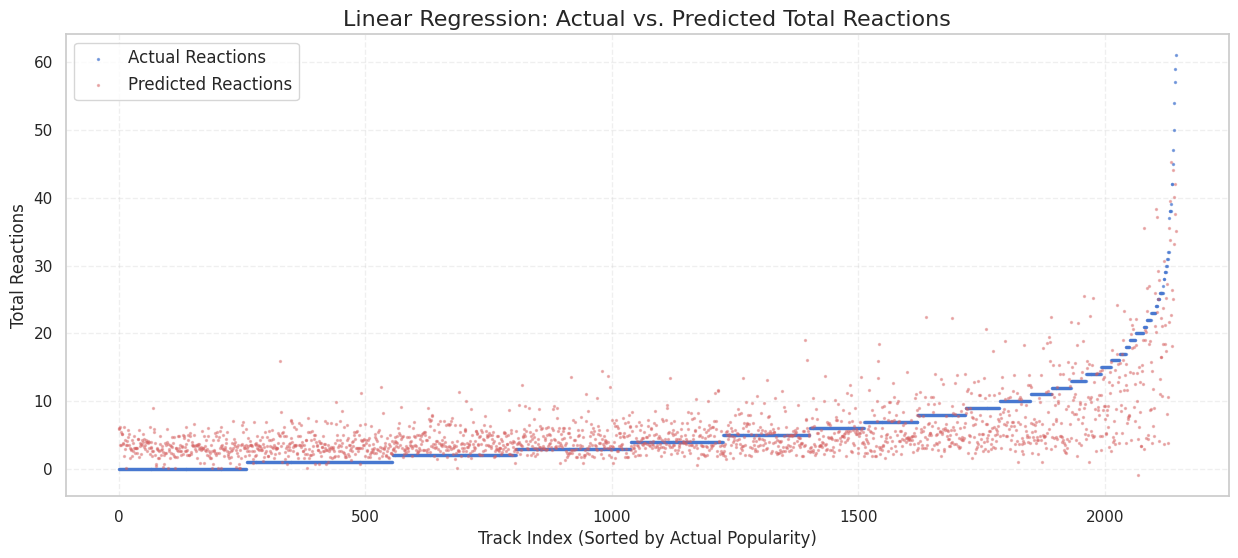

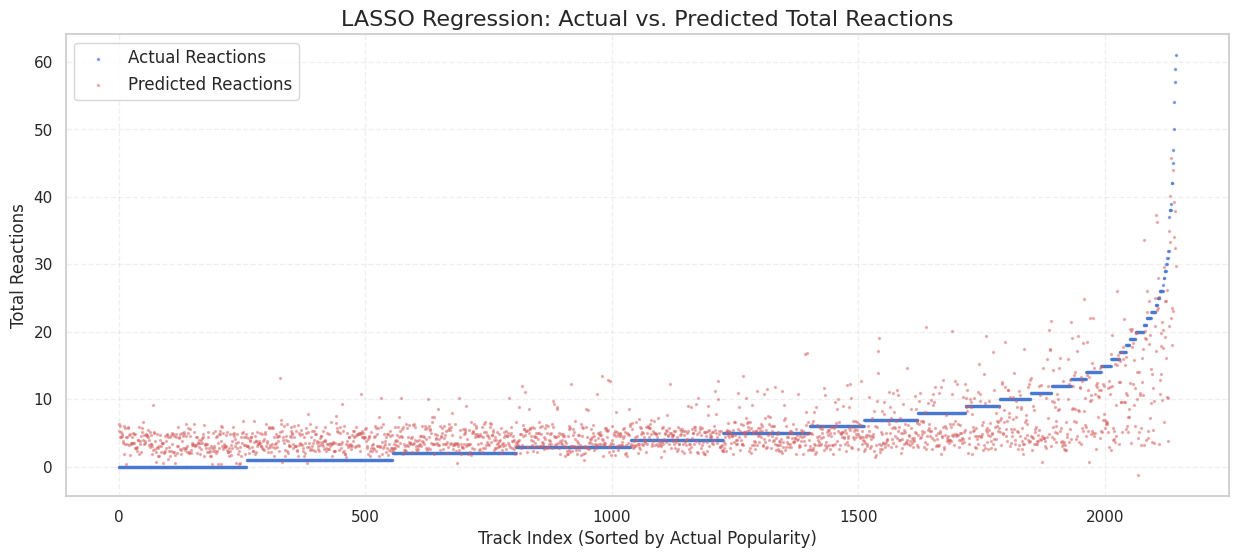

In [7]:
import matplotlib.pyplot as plt
import numpy as np

def plot_actual_vs_predicted(model_name, actuals, predictions):
    """ Helper function to plot line graphs for regression arrays clearly """
    
    actuals = np.array(actuals)
    predictions = np.array(predictions)
    
    # Sort based on actual values to make the plot clean and readable
    sorted_indices = np.argsort(actuals)
    actuals_sorted = actuals[sorted_indices]
    predictions_sorted = predictions[sorted_indices]

    x_vals = np.arange(0, len(actuals_sorted), 1)

    plt.figure(figsize=(15, 6))
    plt.scatter(x_vals, actuals_sorted, c='b', s=2, alpha=0.6, label='Actual Reactions')
    plt.scatter(x_vals, predictions_sorted, c='r', s=2, alpha=0.4, label='Predicted Reactions')

    plt.title(f'{model_name}: Actual vs. Predicted Total Reactions', fontsize=16)
    plt.ylabel('Total Reactions', fontsize=12)
    plt.xlabel('Track Index (Sorted by Actual Popularity)', fontsize=12)
    plt.legend(fontsize=12, loc='upper left')
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.show()

# Show plots for baseline linear methods:
plot_actual_vs_predicted("Linear Regression", y_test, y_pred_lr)
plot_actual_vs_predicted("LASSO Regression", y_test, y_pred_lasso)

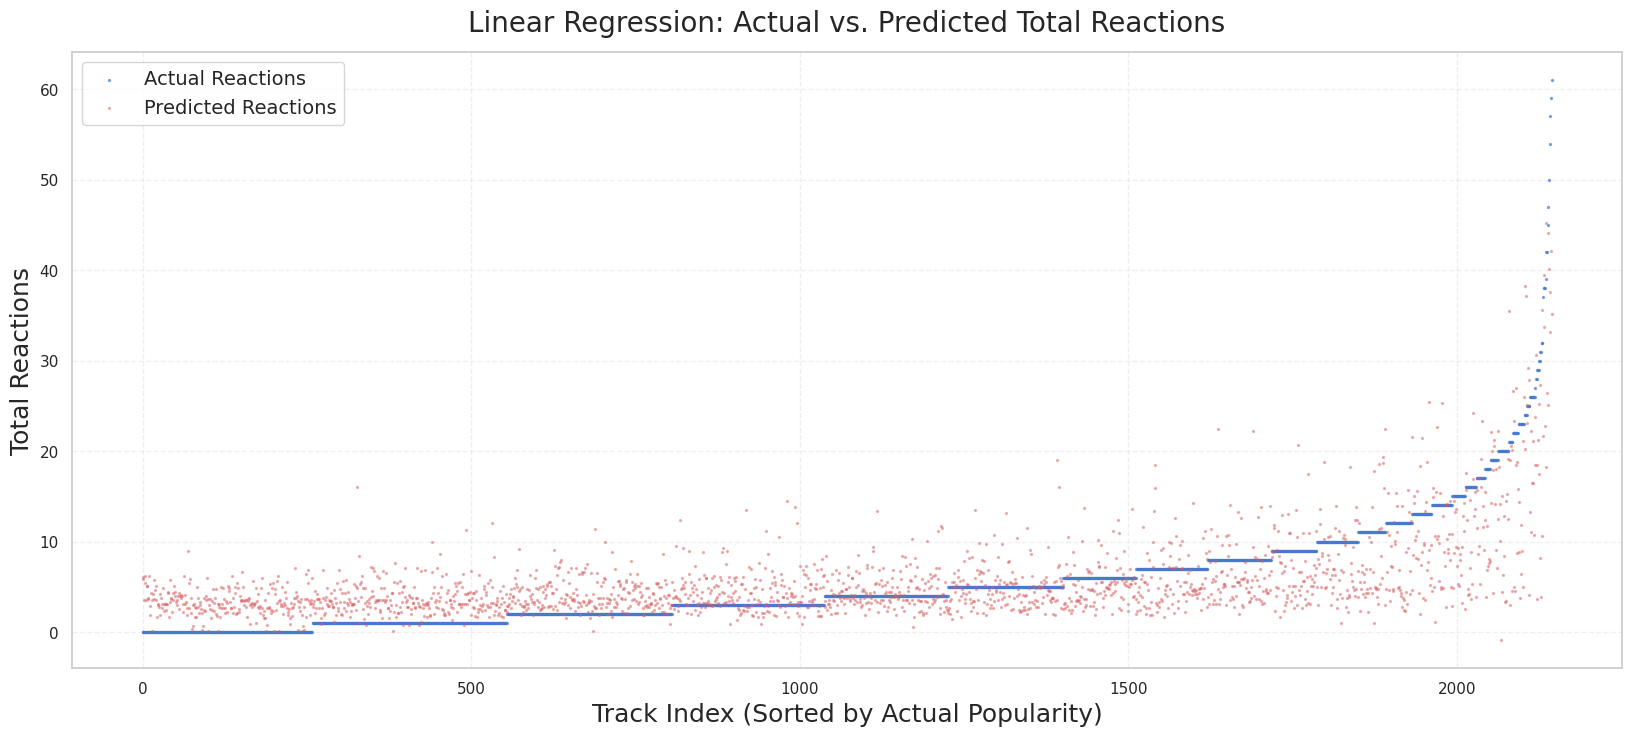

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# Convert to numpy arrays for easy indexing and sorting
actuals = np.array(y_test)
predictions = np.array(y_pred_lr)

# Sort based on actual values to make the plot clean and readable
sorted_indices = np.argsort(actuals)
actuals_sorted = actuals[sorted_indices]
predictions_sorted = predictions[sorted_indices]

# Generate X-axis values (0 to number of test samples)
x = np.arange(0, len(actuals_sorted), 1)

plt.figure(figsize=(20, 8))
plt.scatter(x, actuals_sorted, c='b', s=2, alpha=0.6, label='Actual Reactions')
plt.scatter(x, predictions_sorted, c='r', s=2, alpha=0.4, label='Predicted Reactions')

plt.title('Linear Regression: Actual vs. Predicted Total Reactions', fontsize=20, pad=15)
plt.ylabel('Total Reactions', fontsize=18)
plt.xlabel('Track Index (Sorted by Actual Popularity)', fontsize=18)
plt.legend(fontsize=14, loc='upper left')
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

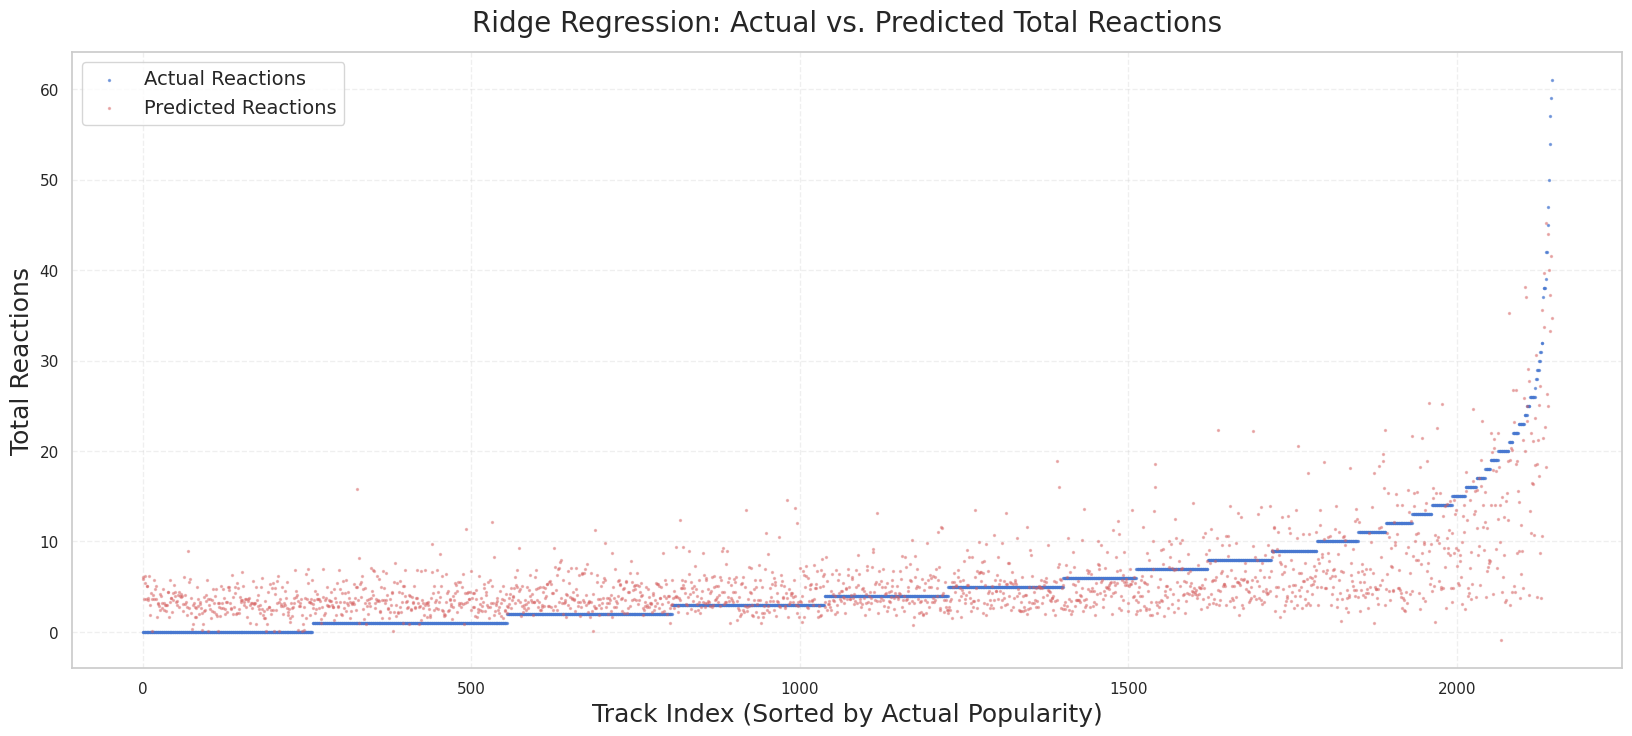

In [9]:
# Extract predictions from your Ridge cross-validation model
predictions_ridge = np.array(y_pred_ridge)

# Sort based on the same actual values index
predictions_ridge_sorted = predictions_ridge[sorted_indices]

plt.figure(figsize=(20, 8))
plt.scatter(x, actuals_sorted, c='b', s=2, alpha=0.6, label='Actual Reactions')
plt.scatter(x, predictions_ridge_sorted, c='r', s=2, alpha=0.4, label='Predicted Reactions')

plt.title('Ridge Regression: Actual vs. Predicted Total Reactions', fontsize=20, pad=15)
plt.ylabel('Total Reactions', fontsize=18)
plt.xlabel('Track Index (Sorted by Actual Popularity)', fontsize=18)
plt.legend(fontsize=14, loc='upper left')
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

### 🧠 1.2 Kernel Regression & Advanced Models

Linear algorithms attempt to fit a straight hyperplane. If our underlying data forms complex nonlinear patterns, our linear baseline might underfit. **Kernel Regression (Kernel Ridge)** uses the Kernel Trick to project the features into high-dimensional space implicitly, capturing these winding curves!

We'll also implement **Decision Tree Regression** (an optional bonus tree-based model) as it solves nonlinearity by splitting feature spaces instead!

📊 --- Kernel Regression (RBF) Metrics ---
🔹 Mean Squared Error (MSE): 20.7579
🔹 Mean Absolute Error (MAE): 3.0593
🔹 Mean Absolute Percentage Error (MAPE): 1694502291489724.2500
🔹 Root Mean Squared Logarithmic Error (RMSLE): 0.7224
🔹 Median Absolute Error (MedAE): 2.2803
🔹 R² Score: 0.4762

📊 --- Decision Tree Regression Metrics ---
🔹 Mean Squared Error (MSE): 18.7943
🔹 Mean Absolute Error (MAE): 2.9958
🔹 Mean Absolute Percentage Error (MAPE): 1607004756807022.2500
🔹 Root Mean Squared Logarithmic Error (RMSLE): 0.7061
🔹 Median Absolute Error (MedAE): 2.2628
🔹 R² Score: 0.5257



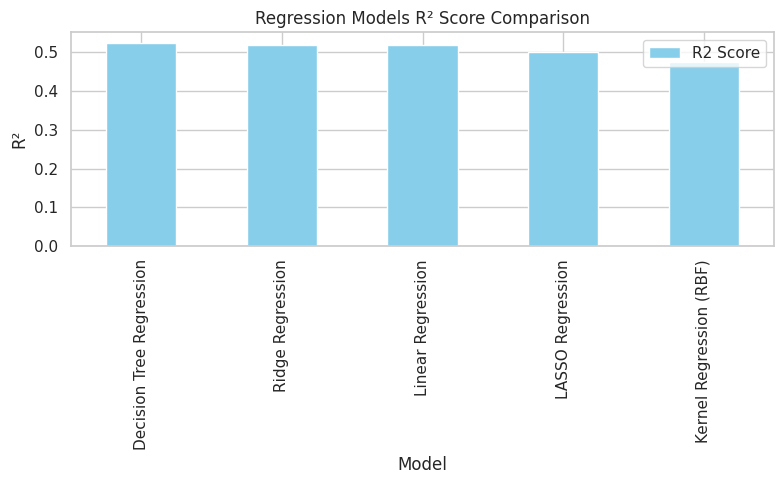

In [ ]:
# --- Kernel Ridge Regression ---
# RBF matches features based on their localized gaussian distance.
kr_model = KernelRidge(kernel='rbf', alpha=1.0, gamma=0.1)
kr_model.fit(X_train_scaled, y_train)
y_pred_kr = kr_model.predict(X_test_scaled)
evaluate_regression("Kernel Regression (RBF)", y_test, y_pred_kr)

# --- Decision Tree Regression (Bonus) ---
dt_model = DecisionTreeRegressor(max_depth=5, random_state=42)
dt_model.fit(X_train_scaled, y_train)
y_pred_dt = dt_model.predict(X_test_scaled)
evaluate_regression("Decision Tree Regression", y_test, y_pred_dt)

# Let's cleanly plot out R2 scores comparison for visualization!
pd.DataFrame([
    {'Model': k, 'R2 Score': v['R2']} for k, v in regression_results.items()
]).sort_values(by='R2 Score', ascending=False).set_index('Model').plot(kind='bar', color='skyblue', figsize=(8,5))
plt.title("Regression Models R² Score Comparison")
plt.ylabel("R²")
plt.tight_layout()
plt.show()

### 🗣️ Discussion Questions (Regression)

**1️⃣ Choose the best regression metric for your dataset and justify.**
> **MSE vs MAE vs MAPE vs $R^2$:** 
> For predicting `total_reactions`, **MAE (Mean Absolute Error)** or **$R^2$ (Coefficient of Determination)** are often the best primary metrics. 
`total_reactions` on a Telegram channel can fluctuate wildly, leading to massive outliers (e.g., highly viral tracks). Because **MSE** squares the errors, it will excessively penalize those few outlier tracks, skewing interpretation. **MAE** tells us exactly how far off (in absolute reaction numbers) our predictions are on average, making it easy to interpret! 
Conversely, **MAPE (Percentage Error)** can be unreliable and mathematically unstable if some tracks sit very close to zero total reactions (as division by near-zero inflates MAPE toward infinity).

**2️⃣ Explain when each regression model is preferable.**
> - **Linear Regression:** The fastest and most interpretable model, preferable when relationships are highly linear and the number of features restricts overfitting.
> - **Ridge Regression:** Excellent when you have many highly correlated (co-linear) features. Its L2 penalty smoothly pulls coefficients toward zero, preventing extreme variances.
> - **LASSO Regression:** Functions identically to Ridge except its L1 penalty acts as **feature selection**. Preferable when we suspect that multiple metrics (e.g., `senders_total_dislikes` etc.) are useless and we want them discarded entirely ($W_{weight} = 0$).
> - **Decision Trees:** Prefers instances where relationships are strictly non-linear and conditional feature crossing exists (e.g. tracks from X artist only explode when Y feature is true).

**3️⃣ Briefly explain the kernel trick in a few sentences and how it can help achieve better regression results.**
> The **Kernel Trick** is a mathematical shortcut extending linear algorithms (like Ridge Regression or SVMs) allowing them to solve non-linear problems. Instead of manually creating polynomials or manipulating existing features, a Kernel function (like RBF) computes the dot-product similarity (distance vector) between feature inputs as if they were already morphed into an infinite-dimensional space.
If `total_reactions` is linearly inseparable in its low dimensions, Kernel Regression intrinsically reshapes the space so linear decision planes pass through flawlessly, netting us higher accuracy curves without the catastrophic computational cost!

---

## 2️⃣ 🟢🔴 Binary Classification Methods

Here, we pivot our context to a discrete outcome with two possibilities (e.g., whether a track went viral or not, or active vs. inactive users). We'll test models to see which best differentiates these binary boundaries.

**Tasks Included:**
*   Implementing **Logistic Regression, SVM, Kernel SVM, KNN, Decision Trees,** and **Random Forests**.
*   Hyperparameter Tuning (such as **K** for KNN, **max-depth** for Decision Trees).
*   Evaluating with metrics like **Accuracy, Precision, Recall, F1-Score, Confusion Matrix,** and plotting the **ROC Curve / AUC**.
*   Discussing regularization on decision trees & comparing basic SVM explicitly to Kernel SVM.

⬇️ *Define binary target threshold, apply models, and plot decision boundaries/ROC curves below!* ⬇️

---

## 3️⃣ 🎨 Multiclass Classification Methods

Real-world scenarios rarely fall into just two boxes. We'll introduce a target feature with at least **4 distinct classes** (e.g., categorizing activity tiers from "Low" to "Outstanding").

**Tasks Included:**
*   Implementing **Multiclass SVM, Multiclass Logistic Regression (OVR/Multinomial), Multiclass KNN (Tuned), Multiclass Decision Trees**, and advanced trees such as **Boosting** (XGBoost, LightGBM, AdaBoost, CatBoost).
*   Scoring implementations individually via **Accuracy, Precision (per class), Recall (per class),** and **F1-Scores (Macro, Micro, Weighted)**.
*   Discussing metric preferences theoretically.

⬇️ *Define the multiclass variable, construct estimators, output metric reports below!* ⬇️

---

## 4️⃣ 🤔 Challenging Questions (Bonus)

Let's unpack the theory! Below we provide descriptive textual answers detailing the underlying mechanisms behind our models:

**Questions to answer:**
1. Bias–variance trade-off in regression models.
2. Kernel Regression vs. Linear Regression.
3. L1 vs L2 regularization (LASSO vs. Ridge effects/sparsity).
4. Unreliability of MAPE metric.
5. Outliers' effects on regression models.
6. The impact of class imbalance on binary metrics.
7. Decision boundaries conceptual differentiation.
8. The role and influence of K in KNN.
9. Overfitting constraints in Decision Trees (why they overfit, max_depth limitations, and pruning).
10. Feature Selection behavior in tree-based algorithms.
11. Micro vs Macro vs Weighted F1 variations and behaviors.
12. Multi-label vs. Multiclass fundamental differences.
13. Precision-Recall conceptual trade-off.
14. ROC Curve vs. Precision-Recall Curve.
15. Expanding models creatively natively utilizing unbound resources.

⬇️ *Answer your theoretical insight blocks below!* ⬇️